<a href="https://colab.research.google.com/github/dacostaca/PDS2025_1/blob/Tareas/Tarea_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tarea 2: Señal senoidal que aumenta su frecuencia conforme aumenta el timepo y su transformada de Fourier.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [2]:
def signal_generator(total_time=5.0, init_frec=1.0, final_frec=20.0, samp_rate=1000):
  # Validación de parámetros
    if total_time <= 0:
        raise ValueError("El tiempo total debe ser positivo")
    if init_frec <= 0 or final_frec <= 0:
        raise ValueError("Las frecuencias deben ser positivas")
    if samp_rate < 2 * max(init_frec, final_frec):
        print(f"Advertencia: La tasa de muestreo debería ser al menos el doble de la frecuencia máxima ({max(init_frec, final_frec)} Hz) según el teorema de Nyquist")

    # Generar vector de tiempo
    num_muestras = int(samp_rate * total_time)
    t = np.linspace(0, total_time, num_muestras, endpoint=False)

    # Generar señal senoidal con frecuencia variable
    frec = init_frec + (final_frec - init_frec) * t / total_time
    senal = np.sin(2 * np.pi * frec * t)

    return t, senal, frec



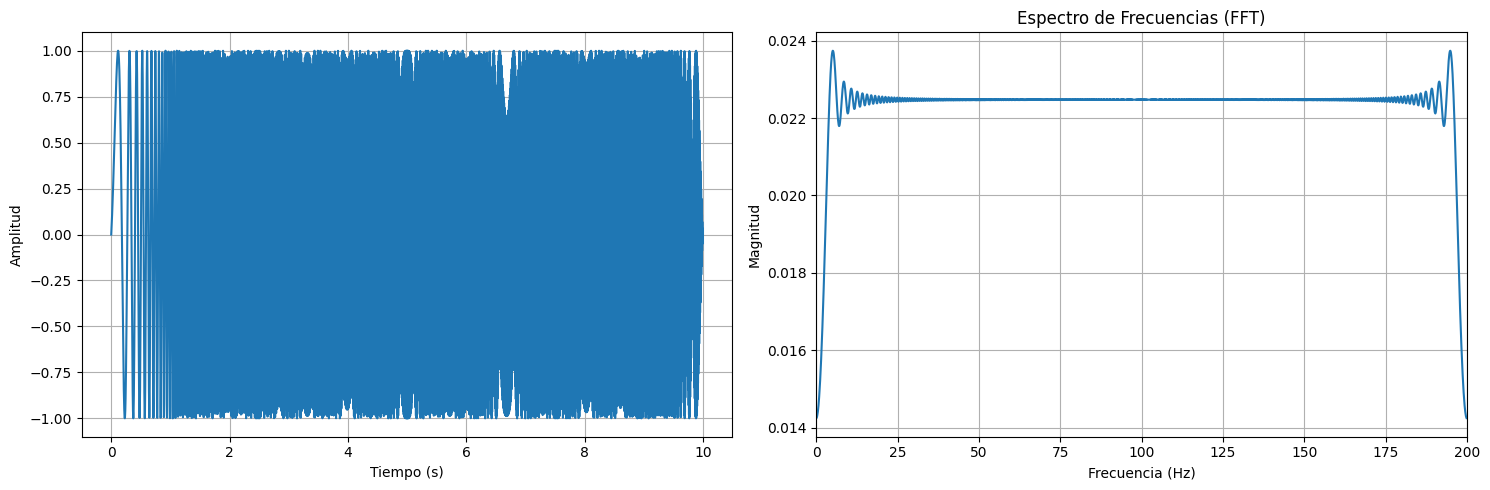

In [13]:
# Configuración de parámetros
tiempo_total = 10.0  # Duración total en segundos
frec_inicial = 1.0   # Frecuencia inicial en Hz
frec_final = 100    # Frecuencia final en Hz
sample = 400

# Crear el vector de tiempo
t, senal, frecuencia = signal_generator(tiempo_total, frec_inicial, frec_final, sample)

# Cálculo de la FFT
n = len(senal)
yf = fft(senal)
xf = fftfreq(n, 1/sample)[:n//2]

# Crear figura con 3 subplots
plt.figure(figsize=(15, 5))

# 1. Señal temporal
plt.subplot(1, 2, 1)
plt.plot(t, senal)
#plt.title(f'Señal Chirp {tipo_barrido.capitalize()}\n{frec_inicial}Hz a {frec_final}Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# 3. Transformada de Fourier
plt.subplot(1, 2, 2)
plt.plot(xf, 2/n * np.abs(yf[0:n//2]))
plt.title('Espectro de Frecuencias (FFT)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)
plt.xlim([0, 2*frec_final])  # Mostramos hasta el doble de la frecuencia máxima

plt.tight_layout()
plt.show()